# Assignments - Numerical greeks

1. Introduce two class variables in Pricer that store the finite difference method (forward, backward, central) to be used in numerical greek calculation, and whether the bump size is absolute or relative. Create two Enums to store the labels. Implement all combinations for delta and gamma calculation.<br>Compare greeks using the analytic and the finite difference approximation on a set of European options and visualize the numerical error. Compare absolute and relative bumping and suggest optimal bump sizes. **(15 points)**

In [55]:
import sys
from pathlib import Path
import numpy as np

current = Path().resolve()
src_path = current / "src"

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from utils import *
from market_data import *
from enums import *
from contract import *
from model import *
from pricer import *

repo_root = next(p for p in [current, *current.parents] if (p / "mkt").exists())
MarketData.market_folder = str(repo_root / "mkt")


MarketData.initialize()

First lets check if the implemented finite difference method for 1 contract and for all 6 combinations. For this I used the Bluechip Banks data in case of a European call option. 

In [56]:
underlying = Stock.BLUECHIP_BANK
spot = MarketData.get_spot()[underlying]

contract = EuropeanContract(
    underlying=underlying,
    derivative_type=PutCallFwd.CALL,
    long_short=LongShort.LONG,
    strike=spot,
    expiry=1.0
)

model = FlatVolModel(underlying)
params = Params()
pricer = EuropeanAnalyticPricer(contract, model, params)

analytic_delta = pricer.calc_delta(GreekMethod.ANALYTIC)
analytic_gamma = pricer.calc_gamma(GreekMethod.ANALYTIC)

bump_sizes = [0.1, 0.01, 0.001, 0.0001]

print("analytic delta =", analytic_delta)
print("analytic gamma =", analytic_gamma)
print()

results = {}

for fm in [FiniteMethod.FORWARD, FiniteMethod.BACKWARD, FiniteMethod.CENTRAL]:
    for bm in [BumpSizeMethod.ABSOLUTE, BumpSizeMethod.RELATIVE]:
        
        key = (fm.value, bm.value)

        delta_errors = []
        gamma_errors = []
        
        for bs in bump_sizes:
            pricer.finitemethod = fm
            pricer.bumpsizemethod = bm
            pricer.relative_bump_size = bs

            num_delta = pricer.calc_delta(GreekMethod.BUMP)
            num_gamma = pricer.calc_gamma(GreekMethod.BUMP)

            delta_errors.append(abs(num_delta - analytic_delta))
            gamma_errors.append(abs(num_gamma - analytic_gamma))

        results[key] = {
        "delta_errors": np.array(delta_errors),
        "gamma_errors": np.array(gamma_errors),
        }

print("bump sizes: ", bump_sizes)
print()

print("DELTA")
print()

for key, value in results.items():
    print(key)
    print("delta errors:", value["delta_errors"])
    print()

print("GAMMA")
print()

for key, value in results.items():
    print(key)
    print("gamma errors:", value["gamma_errors"])
    print()

analytic delta = 0.6261627301230436
analytic gamma = 0.007641774960675401

bump sizes:  [0.1, 0.01, 0.001, 0.0001]

DELTA

('FORWARD', 'ABSOLUTE')
delta errors: [3.81908220e-04 3.82070700e-05 3.82087796e-06 3.82206393e-07]

('FORWARD', 'RELATIVE')
delta errors: [4.66391129e-02 4.94300030e-03 4.97059017e-04 4.97334336e-05]

('BACKWARD', 'ABSOLUTE')
delta errors: [3.82269214e-04 3.82106814e-05 3.82091679e-06 3.82053374e-07]

('BACKWARD', 'RELATIVE')
delta errors: [5.26916990e-02 5.00416157e-03 4.97670693e-04 4.97395516e-05]

('CENTRAL', 'ABSOLUTE')
delta errors: [1.80497055e-07 1.80571813e-09 1.94136929e-11 7.65095765e-11]

('CENTRAL', 'RELATIVE')
delta errors: [3.02629302e-03 3.05806378e-05 3.05838148e-07 3.05897785e-09]

GAMMA

('FORWARD', 'ABSOLUTE')
gamma errors: [1.08341286e-05 1.08304151e-06 1.15211251e-07 1.30892305e-06]

('FORWARD', 'RELATIVE')
gamma errors: [1.42208970e-03 1.41633593e-04 1.41044537e-05 1.40966417e-06]

('BACKWARD', 'ABSOLUTE')
gamma errors: [1.08254572e-05 1.082

Visualizing the results

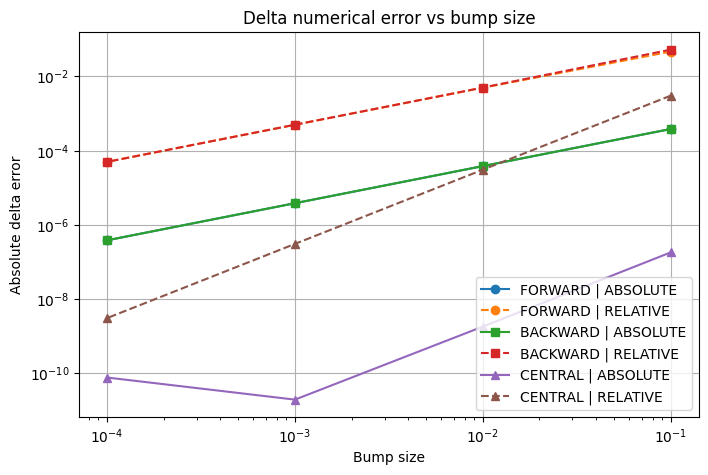

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

styles = {
    ("FORWARD", "ABSOLUTE"): ("o","-"),
    ("FORWARD", "RELATIVE"): ("o","--"),
    ("BACKWARD", "ABSOLUTE"): ("s","-"),
    ("BACKWARD", "RELATIVE"): ("s","--"),
    ("CENTRAL", "ABSOLUTE"): ("^","-"),
    ("CENTRAL", "RELATIVE"): ("^","--"),
}

for key, value in results.items():
    label = f"{key[0]} | {key[1]}"
    marker, linestyle=styles[key]
    plt.plot(
        bump_sizes,
        value["delta_errors"],
        marker=marker,
        linestyle=linestyle,
        label=label
    )

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Bump size")
plt.ylabel("Absolute delta error")
plt.title("Delta numerical error vs bump size")
plt.legend()
plt.grid(True)
plt.show()

In this case the forward absolute, backward absolute errors are really similar as well as the forward relative and backward relative errors, so we can only see one of these graphs on the plot because they are on top of each other. What we can see though, is that the central method is the best by a large margin. 

Similarly to the delta errors, the central method is the best for gamma approximation. What is interesting to see is that very small bump sizes do not necessarily improve numerical accuracy. In case of central absolute case the erros increases with the bump size being smaller. This is due to rounding errors.

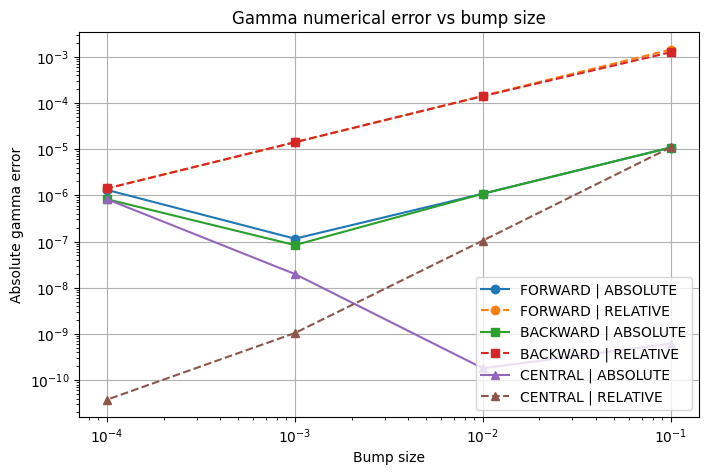

In [58]:
plt.figure(figsize=(8, 5))

for key, value in results.items():
    label = f"{key[0]} | {key[1]}"
    marker, linestyle=styles[key]
    plt.plot(
        bump_sizes,
        value["gamma_errors"],
        marker=marker,
        linestyle=linestyle,
        label=label
    )

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Bump size")
plt.ylabel("Absolute gamma error")
plt.title("Gamma numerical error vs bump size")
plt.legend()
plt.grid(True)
plt.show()

I found this numerically unstable thing interesting, so I investigated it a bit further. Using even smaller bump sizes.

In [61]:
underlying = Stock.BLUECHIP_BANK
spot = MarketData.get_spot()[underlying]

contract = EuropeanContract(
    underlying=underlying,
    derivative_type=PutCallFwd.CALL,
    long_short=LongShort.LONG,
    strike=spot,
    expiry=1.0
)

model = FlatVolModel(underlying)
params = Params()
pricer = EuropeanAnalyticPricer(contract, model, params)

analytic_delta = pricer.calc_delta(GreekMethod.ANALYTIC)
analytic_gamma = pricer.calc_gamma(GreekMethod.ANALYTIC)

bump_sizes = [0.1, 0.01, 0.001, 0.0001, 0.00001, 0.000001, 0.0000001, 0.00000001]


results = {}

for fm in [FiniteMethod.FORWARD, FiniteMethod.BACKWARD, FiniteMethod.CENTRAL]:
    for bm in [BumpSizeMethod.ABSOLUTE, BumpSizeMethod.RELATIVE]:
        
        key = (fm.value, bm.value)

        delta_errors = []
        gamma_errors = []
        
        for bs in bump_sizes:
            pricer.finitemethod = fm
            pricer.bumpsizemethod = bm
            pricer.relative_bump_size = bs

            num_delta = pricer.calc_delta(GreekMethod.BUMP)
            num_gamma = pricer.calc_gamma(GreekMethod.BUMP)

            delta_errors.append(abs(num_delta - analytic_delta))
            gamma_errors.append(abs(num_gamma - analytic_gamma))

        results[key] = {
        "delta_errors": np.array(delta_errors),
        "gamma_errors": np.array(gamma_errors),
        }

What we can see on the plot below is that around bump size 0.0001 the methdos become unstable and the errors start to grow. The relative curves appear shifted because the x-axis shows the bump parameter, not the effective bump. In the relative case, the actual bump is bump_size times spot price which in this case is equal to approximately 130 so the the same effective bump is reached at a much smaller parameter.

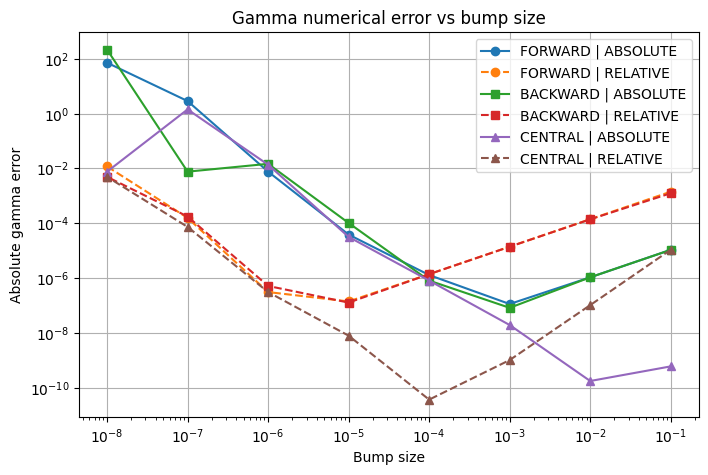

In [62]:
plt.figure(figsize=(8, 5))

for key, value in results.items():
    label = f"{key[0]} | {key[1]}"
    marker, linestyle=styles[key]
    plt.plot(
        bump_sizes,
        value["gamma_errors"],
        marker=marker,
        linestyle=linestyle,
        label=label
    )

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Bump size")
plt.ylabel("Absolute gamma error")
plt.title("Gamma numerical error vs bump size")
plt.legend()
plt.grid(True)
plt.show()

Finally lets compare the methods for a set of options. I used different combinations of strikes and expiries for the Bluechip bank stock

In [63]:
underlying = Stock.BLUECHIP_BANK
spot = MarketData.get_spot()[underlying]

strike_multipliers = [0.8, 0.9, 1.0, 1.1, 1.2]
expiries = [0.25, 0.5, 1.0, 2.0]

option_specs = []
for m in strike_multipliers:
    for expiry in expiries:
        option_specs.append({
            "strike": spot * m,
            "expiry": expiry
        })

option_specs

[{'strike': 104.136, 'expiry': 0.25},
 {'strike': 104.136, 'expiry': 0.5},
 {'strike': 104.136, 'expiry': 1.0},
 {'strike': 104.136, 'expiry': 2.0},
 {'strike': 117.15299999999999, 'expiry': 0.25},
 {'strike': 117.15299999999999, 'expiry': 0.5},
 {'strike': 117.15299999999999, 'expiry': 1.0},
 {'strike': 117.15299999999999, 'expiry': 2.0},
 {'strike': 130.17, 'expiry': 0.25},
 {'strike': 130.17, 'expiry': 0.5},
 {'strike': 130.17, 'expiry': 1.0},
 {'strike': 130.17, 'expiry': 2.0},
 {'strike': 143.187, 'expiry': 0.25},
 {'strike': 143.187, 'expiry': 0.5},
 {'strike': 143.187, 'expiry': 1.0},
 {'strike': 143.187, 'expiry': 2.0},
 {'strike': 156.20399999999998, 'expiry': 0.25},
 {'strike': 156.20399999999998, 'expiry': 0.5},
 {'strike': 156.20399999999998, 'expiry': 1.0},
 {'strike': 156.20399999999998, 'expiry': 2.0}]

In [64]:
bump_sizes = [0.1, 0.01, 0.001, 0.0001, 0.00001, 0.000001, 0.0000001]

records = []

for spec in option_specs:
    contract = EuropeanContract(
        underlying=underlying,
        derivative_type=PutCallFwd.CALL,
        long_short=LongShort.LONG,
        strike=spec["strike"],
        expiry=spec["expiry"]
    )

    model = FlatVolModel(underlying)
    params = Params()
    pricer = EuropeanAnalyticPricer(contract, model, params)

    analytic_delta = pricer.calc_delta(GreekMethod.ANALYTIC)
    analytic_gamma = pricer.calc_gamma(GreekMethod.ANALYTIC)

    for fm in [FiniteMethod.FORWARD, FiniteMethod.BACKWARD, FiniteMethod.CENTRAL]:
        for bm in [BumpSizeMethod.ABSOLUTE, BumpSizeMethod.RELATIVE]:
            for bs in bump_sizes:
                pricer.finitemethod = fm
                pricer.bumpsizemethod = bm
                pricer.relative_bump_size = bs

                num_delta = pricer.calc_delta(GreekMethod.BUMP)
                num_gamma = pricer.calc_gamma(GreekMethod.BUMP)

                records.append({
                    "strike": spec["strike"],
                    "expiry": spec["expiry"],
                    "finite_method": fm.value,
                    "bump_method": bm.value,
                    "bump_size": bs,
                    "analytic_delta": analytic_delta,
                    "analytic_gamma": analytic_gamma,
                    "num_delta": num_delta,
                    "num_gamma": num_gamma,
                    "delta_error": abs(num_delta - analytic_delta),
                    "gamma_error": abs(num_gamma - analytic_gamma),
                })

df = pd.DataFrame(records)
df.head()

,strike,expiry,finite_method,bump_method,bump_size,analytic_delta,analytic_gamma,num_delta,num_gamma,delta_error,gamma_error
0,104.136,0.25,FORWARD,ABSOLUTE,0.10000,0.854035,0.006917,0.854380,0.006890,3.454026e-04,2.730109e-05
1,104.136,0.25,FORWARD,ABSOLUTE,0.01000,0.854035,0.006917,0.854069,0.006914,3.458124e-05,2.733169e-06
2,104.136,0.25,FORWARD,ABSOLUTE,0.00100,0.854035,0.006917,0.854038,0.006917,3.458543e-06,2.825068e-07
3,104.136,0.25,FORWARD,ABSOLUTE,0.00010,0.854035,0.006917,0.854035,0.006919,3.458542e-07,2.104917e-06
4,104.136,0.25,FORWARD,ABSOLUTE,0.00001,0.854035,0.006917,0.854035,0.007105,3.321535e-08,1.882671e-04


In the table below we can see the mean and max errors for both delta and gamma for all combinations.

In [65]:
summary = (
    df.groupby(["finite_method", "bump_method", "bump_size"], as_index=False)
      .agg(
          mean_delta_error=("delta_error", "mean"),
          mean_gamma_error=("gamma_error", "mean"),
          max_delta_error=("delta_error", "max"),
          max_gamma_error=("gamma_error", "max"),
      )
)

summary

,finite_method,bump_method,bump_size,mean_delta_error,mean_gamma_error,max_delta_error,max_gamma_error
0,BACKWARD,ABSOLUTE,1.000000e-07,9.449137e-08,1.120800e+00,2.151646e-07,3.558205e+00
1,BACKWARD,ABSOLUTE,1.000000e-06,1.062748e-08,1.921097e-02,3.042347e-08,4.797922e-02
2,BACKWARD,ABSOLUTE,1.000000e-05,4.385027e-08,1.558667e-04,8.666888e-08,4.878078e-04
3,BACKWARD,ABSOLUTE,1.000000e-04,4.410010e-07,1.445203e-06,8.853900e-07,4.432513e-06
4,BACKWARD,ABSOLUTE,1.000000e-03,4.410601e-06,1.612580e-07,8.854660e-06,5.390315e-07
5,BACKWARD,ABSOLUTE,1.000000e-02,4.410693e-05,1.592426e-06,8.854275e-05,5.508603e-06
6,BACKWARD,ABSOLUTE,1.000000e-01,4.411576e-04,1.593091e-05,8.850399e-04,5.513409e-05
7,BACKWARD,RELATIVE,1.000000e-07,5.819706e-08,1.448878e-04,1.154058e-07,3.685443e-04
8,BACKWARD,RELATIVE,1.000000e-06,5.740952e-07,1.053235e-06,1.152590e-06,2.757539e-06
9,BACKWARD,RELATIVE,1.000000e-05,5.741289e-06,2.058394e-07,1.152609e-05,7.250964e-07


I decided to give the optimal bump sizes and suggestions based on the mean values. Potting the results:

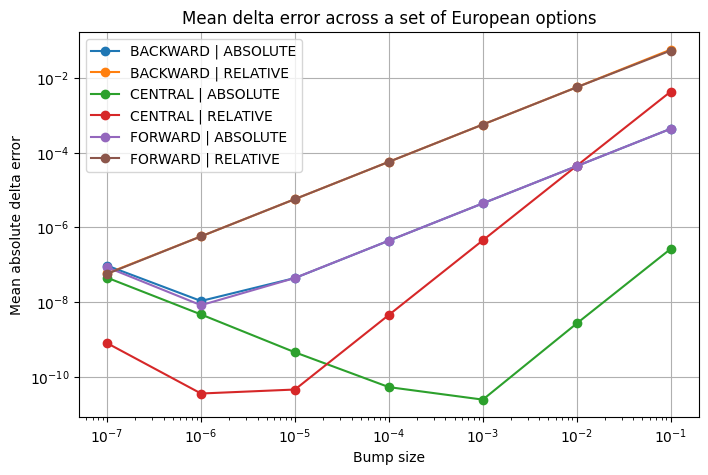

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

for (fm, bm), grp in summary.groupby(["finite_method", "bump_method"]):
    grp = grp.sort_values("bump_size")
    plt.plot(grp["bump_size"], grp["mean_delta_error"], marker="o", label=f"{fm} | {bm}")

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Bump size")
plt.ylabel("Mean absolute delta error")
plt.title("Mean delta error across a set of European options")
plt.grid(True)
plt.legend()
plt.show()

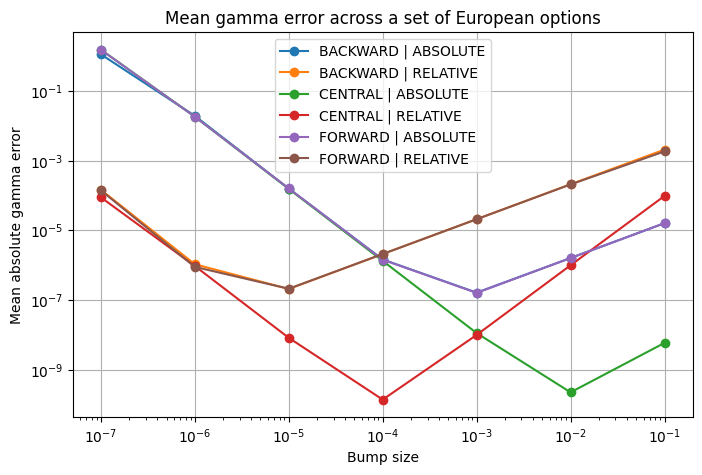

In [67]:
plt.figure(figsize=(8, 5))

for (fm, bm), grp in summary.groupby(["finite_method", "bump_method"]):
    grp = grp.sort_values("bump_size")
    plt.plot(grp["bump_size"], grp["mean_gamma_error"], marker="o", label=f"{fm} | {bm}")

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Bump size")
plt.ylabel("Mean absolute gamma error")
plt.title("Mean gamma error across a set of European options")
plt.grid(True)
plt.legend()
plt.show()

Based on the plots the central difference scheme performs best for both delta and gamma. The optimal bump is not arbitrarily small, we can see the best results at an intermediate effective bump size, while very small bumps increase numerical error, especially for gamma.

Delta: The best bump size for central absolute is $\sim 10^{-3}$. The best bump size for central relative is $\sim 10^{-5}, 10^{-6}$


Gamma: The best bump size for central absolute is $\sim 10^{-2}$. The best bump size for central relative is $\sim 10^{-4}$.
